### STARVED COMPARISON

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import wilcoxon, mannwhitneyu


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

os.makedirs('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/starved-comparison', exist_ok=True)


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['role'] = df1['track_id'].map({0: 'starved', 1: 'fed'})
df1 = df1[df1['role'] == 'starved']
df1['condition'] = 'starved(f-s)'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['condition'] = 'starved(s-s)'

df = pd.concat([df1, df2], ignore_index=True)



df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df = df.sort_values(['condition', 'file', 'track_id', 'rel_frame'])


metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['condition', 'file', 'track_id', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

# Average larvae within each file before stats, so each recording contributes once.
first_interaction_file = (
    first_interaction
    .groupby(['condition', 'file', 'interaction_group', 'rel_frame'])[metrics]
    .mean()
    .reset_index()
)


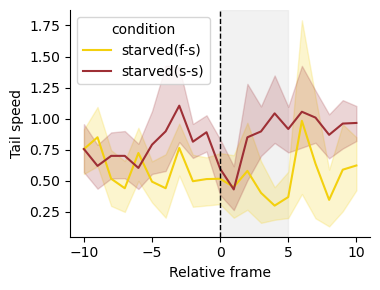

In [ ]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='condition',
    hue_order=['starved(f-s)', 'starved(s-s)'],
    palette={'starved(f-s)': '#F3D00E', 'starved(s-s)': '#9E2F35'},
    errorbar=('ci', 95)
)

plt.axvspan(0, 5, color='0.9', alpha=0.5, zorder=0)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('Tail speed')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/starved-comparison/speed.pdf', format='pdf')
plt.show()


In [3]:
# Frames 1-5: average tail speed per file, then independent starved(f-s) vs starved(s-s) test
speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_5)
print(speed_1_5.mean())

stat, p = mannwhitneyu(speed_1_5['starved(f-s)'].dropna(), speed_1_5['starved(s-s)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-5, starved(f-s) vs starved(s-s): U={stat:.3g}, p={p:.3g}")


condition,starved(f-s),starved(s-s)
file,,
2026-04-28_12-17-10_td5.tracks.feather,0.456355,NaN
2026-05-11_11-19-24_td4.tracks.feather,0.484533,NaN
2026-05-12_14-37-56_td2.tracks.feather,NaN,1.119498
2026-05-12_14-44-29_td4.tracks.feather,0.575512,NaN
2026-05-18_11-59-20_td4.tracks.feather,NaN,0.733948
2026-05-18_12-00-57_td1.tracks.feather,NaN,0.810640
2026-05-19_12-21-24_td1.tracks.feather,NaN,0.649907
2026-05-19_12-25-59_td17.tracks.feather,0.228499,NaN
2026-06-05_12-09-45_td1.tracks.feather,NaN,0.480958


condition
starved(f-s)    0.419493
starved(s-s)    0.826882
dtype: float64
Mann-Whitney U test, frames 1-5, starved(f-s) vs starved(s-s): U=4, p=0.00373


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_40881/2691801931.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


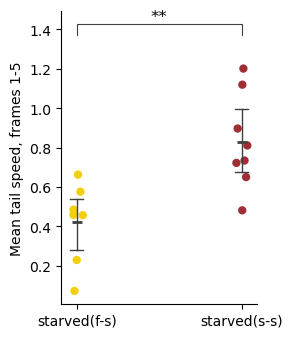

In [ ]:
# Plot the values used in the frames 1-5 speed test
speed_1_5_plot = speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved(f-s)', 'starved(s-s)'],
    var_name='condition',
    value_name='speed_tail'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['starved(f-s)', 'starved(s-s)'],
    hue='condition',
    palette={'starved(f-s)': '#F3D00E', 'starved(s-s)': '#9E2F35'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['starved(f-s)', 'starved(s-s)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = speed_1_5_plot['speed_tail'].max()
ymin = speed_1_5_plot['speed_tail'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean tail speed, frames 1-5')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/starved-comparison/speed_mean.pdf', format='pdf')
plt.show()


In [5]:
# Frames 1-5 after contact compared with frames -5 to -1 before contact, tail speed
pre_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(-5, -1)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

post_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

change_speed_1_5 = post_speed_1_5 - pre_speed_1_5

display(pd.concat({'pre': pre_speed_1_5, 'post': post_speed_1_5, 'post_minus_pre': change_speed_1_5}, axis=1))
print('Mean pre:')
print(pre_speed_1_5.mean())
print('\nMean post:')
print(post_speed_1_5.mean())
print('\nMean post - pre:')
print(change_speed_1_5.mean())

starved_fs_pairs = pd.concat([pre_speed_1_5['starved(f-s)'], post_speed_1_5['starved(f-s)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_starved_fs = wilcoxon(starved_fs_pairs['pre'], starved_fs_pairs['post'])
print(f"starved(f-s) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved_fs:.3g}")

starved_ss_pairs = pd.concat([pre_speed_1_5['starved(s-s)'], post_speed_1_5['starved(s-s)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_starved_ss = wilcoxon(starved_ss_pairs['pre'], starved_ss_pairs['post'])
print(f"starved(s-s) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved_ss:.3g}")

stat, change_p = mannwhitneyu(change_speed_1_5['starved(f-s)'].dropna(), change_speed_1_5['starved(s-s)'].dropna(), alternative='two-sided')
print(f"Change score, tail speed starved(f-s) vs starved(s-s), frames 1-5: U={stat:.3g}, p={change_p:.3g}")


pre               \
condition                               starved(f-s) starved(s-s)   
file                                                                
2026-04-28_12-17-10_td5.tracks.feather      0.496749          NaN   
2026-05-11_11-19-24_td4.tracks.feather      0.578848          NaN   
2026-05-12_14-37-56_td2.tracks.feather           NaN     0.768671   
2026-05-12_14-44-29_td4.tracks.feather      0.645438          NaN   
2026-05-18_11-59-20_td4.tracks.feather           NaN     0.622170   
2026-05-18_12-00-57_td1.tracks.feather           NaN     1.187068   
2026-05-19_12-21-24_td1.tracks.feather           NaN     0.812966   
2026-05-19_12-25-59_td17.tracks.feather     0.825529          NaN   
2026-06-05_12-09-45_td1.tracks.feather           NaN     0.754199   
2026-06-22_11-57-42_td4.tracks.feather      0.620144          NaN   
2026-06-22_11-59-31_td5.tracks.feather      0.142290          NaN   
2026-06-22_12-04-28_td11.tracks.feather          NaN     1.129584   
2026-06-22_12-04-58_td9.tracks.feather           NaN     1.413668   
2026-06-23_15-46-29_td8.tracks.feather           NaN     0.505302   
2026-06-23_15-48-53_td5.tracks.feather      0.476297          NaN   

                                                post               \
condition                               starved(f-s) starved(s-s)   
file                                                                
2026-04-28_12-17-10_td5.tracks.feather      0.456355          NaN   
2026-05-11_11-19-24_td4.tracks.feather      0.484533          NaN   
2026-05-12_14-37-56_td2.tracks.feather           NaN     1.119498   
2026-05-12_14-44-29_td4.tracks.feather      0.575512          NaN   
2026-05-18_11-59-20_td4.tracks.feather           NaN     0.733948   
2026-05-18_12-00-57_td1.tracks.feather           NaN     0.810640   
2026-05-19_12-21-24_td1.tracks.feather           NaN     0.649907   
2026-05-19_12-25-59_td17.tracks.feather     0.228499          NaN   
2026-06-05_12-09-45_td1.tracks.feather           NaN     0.480958   
2026-06-22_11-57-42_td4.tracks.feather      0.662264          NaN   
2026-06-22_11-59-31_td5.tracks.feather      0.071307          NaN   
2026-06-22_12-04-28_td11.tracks.feather          NaN     0.721980   
2026-06-22_12-04-58_td9.tracks.feather           NaN     1.201368   
2026-06-23_15-46-29_td8.tracks.feather           NaN     0.896755   
2026-06-23_15-48-53_td5.tracks.feather      0.457978          NaN   

                                        post_minus_pre               
condition                                 starved(f-s) starved(s-s)  
file                                                                 
2026-04-28_12-17-10_td5.tracks.feather       -0.040395          NaN  
2026-05-11_11-19-24_td4.tracks.feather       -0.094315          NaN  
2026-05-12_14-37-56_td2.tracks.feather             NaN     0.350827  
2026-05-12_14-44-29_td4.tracks.feather       -0.069926          NaN  
2026-05-18_11-59-20_td4.tracks.feather             NaN     0.111778  
2026-05-18_12-00-57_td1.tracks.feather             NaN    -0.376428  
2026-05-19_12-21-24_td1.tracks.feather             NaN    -0.163059  
2026-05-19_12-25-59_td17.tracks.feather      -0.597030          NaN  
2026-06-05_12-09-45_td1.tracks.feather             NaN    -0.273241  
2026-06-22_11-57-42_td4.tracks.feather        0.042121          NaN  
2026-06-22_11-59-31_td5.tracks.feather       -0.070983          NaN  
2026-06-22_12-04-28_td11.tracks.feather            NaN    -0.407604  
2026-06-22_12-04-58_td9.tracks.feather             NaN    -0.212300  
2026-06-23_15-46-29_td8.tracks.feather             NaN     0.391453  
2026-06-23_15-48-53_td5.tracks.feather       -0.018319          NaN

Mean pre:
condition
starved(f-s)    0.540757
starved(s-s)    0.899204
dtype: float64

Mean post:
condition
starved(f-s)    0.419493
starved(s-s)    0.826882
dtype: float64

Mean post - pre:
condition
starved(f-s)   -0.121264
starved(s-s)   -0.072322
dtype: float64
starved(f-s) pre vs post, tail speed frames 1-5: W=3, p=0.0781
starved(s-s) pre vs post, tail speed frames 1-5: W=13, p=0.547
Change score, tail speed starved(f-s) vs starved(s-s), frames 1-5: U=30, p=0.867


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_40881/3345276573.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


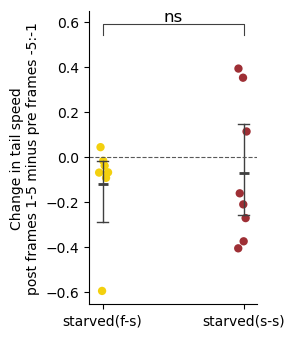

In [ ]:
# Plot the values used in the frames 1-5 speed change-score test
change_speed_1_5_plot = change_speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved(f-s)', 'starved(s-s)'],
    var_name='condition',
    value_name='speed_change'
)

if change_p < 0.001:
    stars = '***'
elif change_p < 0.01:
    stars = '**'
elif change_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['starved(f-s)', 'starved(s-s)'],
    hue='condition',
    palette={'starved(f-s)': '#F3D00E', 'starved(s-s)': '#9E2F35'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['starved(f-s)', 'starved(s-s)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

plt.axhline(0, color='0.35', linewidth=0.8, linestyle='--')

ymax = change_speed_1_5_plot['speed_change'].max()
ymin = change_speed_1_5_plot['speed_change'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Change in tail speed\npost frames 1-5 minus pre frames -5:-1')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/starved-comparison/speed_baseline_change.pdf', format='pdf')
plt.show()


In [7]:
# Test whether each condition changes from before to after contact, frames 1-5
starved_fs_pairs = pd.concat([pre_speed_1_5['starved(f-s)'], post_speed_1_5['starved(f-s)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_starved_fs = wilcoxon(starved_fs_pairs['pre'], starved_fs_pairs['post'])
print(f"starved(f-s) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved_fs:.3g}")
print(f"starved(f-s) mean change: {change_speed_1_5['starved(f-s)'].mean():.3g}")

starved_ss_pairs = pd.concat([pre_speed_1_5['starved(s-s)'], post_speed_1_5['starved(s-s)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_starved_ss = wilcoxon(starved_ss_pairs['pre'], starved_ss_pairs['post'])
print(f"starved(s-s) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved_ss:.3g}")
print(f"starved(s-s) mean change: {change_speed_1_5['starved(s-s)'].mean():.3g}")


starved(f-s) pre vs post, tail speed frames 1-5: W=3, p=0.0781
starved(f-s) mean change: -0.121
starved(s-s) pre vs post, tail speed frames 1-5: W=13, p=0.547
starved(s-s) mean change: -0.0723


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_40881/1614350450.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_40881/1614350450.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


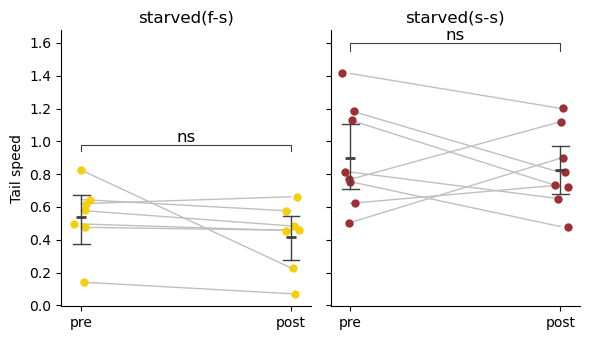

In [ ]:
# Plot pre vs post tail speed within each condition, frames 1-5
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

for ax, condition, color, test_p in zip(
    axes,
    ['starved(f-s)', 'starved(s-s)'],
    ['#F3D00E', '#9E2F35'],
    [p_starved_fs, p_starved_ss]
):
    plot_data = pd.DataFrame({
        'file': pre_speed_1_5.index,
        'pre': pre_speed_1_5[condition],
        'post': post_speed_1_5[condition]
    }).dropna()
    long_plot_data = plot_data.melt(
        id_vars='file',
        value_vars=['pre', 'post'],
        var_name='time',
        value_name='speed_tail'
    )

    if test_p < 0.001:
        stars = '***'
    elif test_p < 0.01:
        stars = '**'
    elif test_p < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    for _, row in plot_data.iterrows():
        ax.plot([0, 1], [row['pre'], row['post']], color='0.75', linewidth=1, zorder=1)

    sns.stripplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        color=color,
        size=6,
        jitter=0.04,
        ax=ax,
        zorder=2
    )

    sns.pointplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        errorbar=('ci', 95),
        color='0.25',
        markers='_',
        linestyles='none',
        capsize=0.08,
        err_kws={'linewidth': 1},
        join=False,
        ax=ax
    )

    ymax = long_plot_data['speed_tail'].max()
    ymin = long_plot_data['speed_tail'].min()
    y_range = ymax - ymin if ymax > ymin else 1
    y = ymax + y_range * 0.15
    h = y_range * 0.05
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
    ax.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

    ax.set_title(condition)
    ax.set_xlabel('')
    ax.set_ylabel('Tail speed' if condition == 'starved(f-s)' else '')

sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/starved-comparison/speed_baseline_change_within_condition.pdf', format='pdf')
plt.show()


In [9]:
# Frames 1-10: average tail speed per file, then independent starved(f-s) vs starved(s-s) test
speed_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_10)
print(speed_1_10.mean())

stat, p = mannwhitneyu(speed_1_10['starved(f-s)'].dropna(), speed_1_10['starved(s-s)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-10, starved(f-s) vs starved(s-s): U={stat:.3g}, p={p:.3g}")


condition,starved(f-s),starved(s-s)
file,,
2026-04-28_12-17-10_td5.tracks.feather,0.334330,NaN
2026-05-11_11-19-24_td4.tracks.feather,1.123556,NaN
2026-05-12_14-37-56_td2.tracks.feather,NaN,1.053093
2026-05-12_14-44-29_td4.tracks.feather,0.527475,NaN
2026-05-18_11-59-20_td4.tracks.feather,NaN,0.640459
2026-05-18_12-00-57_td1.tracks.feather,NaN,0.815203
2026-05-19_12-21-24_td1.tracks.feather,NaN,0.792197
2026-05-19_12-25-59_td17.tracks.feather,0.534560,NaN
2026-06-05_12-09-45_td1.tracks.feather,NaN,0.792807


condition
starved(f-s)    0.527296
starved(s-s)    0.899198
dtype: float64
Mann-Whitney U test, frames 1-10, starved(f-s) vs starved(s-s): U=7, p=0.014


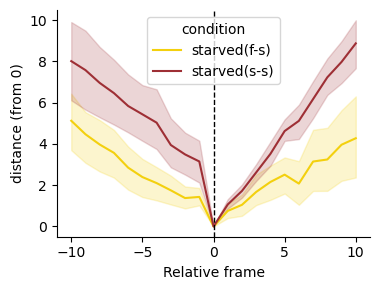

In [ ]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='condition',
    hue_order=['starved(f-s)', 'starved(s-s)'],
    palette={'starved(f-s)': '#F3D00E', 'starved(s-s)': '#9E2F35'},
    errorbar=('ci', 95)
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('distance (from 0)')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/starved-comparison/distance_from_0.pdf', format='pdf')
plt.show()


In [11]:
# Frames 1-5: average distance_from_0 per file, then independent starved(f-s) vs starved(s-s) test
distance_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_5)
print(distance_1_5.mean())

stat, p = mannwhitneyu(distance_1_5['starved(f-s)'].dropna(), distance_1_5['starved(s-s)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-5, starved(f-s) vs starved(s-s): U={stat:.3g}, p={p:.3g}")


condition,starved(f-s),starved(s-s)
file,,
2026-04-28_12-17-10_td5.tracks.feather,1.599526,NaN
2026-05-11_11-19-24_td4.tracks.feather,1.804506,NaN
2026-05-12_14-37-56_td2.tracks.feather,NaN,2.764659
2026-05-12_14-44-29_td4.tracks.feather,3.086688,NaN
2026-05-18_11-59-20_td4.tracks.feather,NaN,2.107330
2026-05-18_12-00-57_td1.tracks.feather,NaN,3.093874
2026-05-19_12-21-24_td1.tracks.feather,NaN,2.684750
2026-05-19_12-25-59_td17.tracks.feather,1.984690,NaN
2026-06-05_12-09-45_td1.tracks.feather,NaN,1.893870


condition
starved(f-s)    1.627634
starved(s-s)    2.709921
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-5, starved(f-s) vs starved(s-s): U=6, p=0.00932


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_40881/3024456075.py:35: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


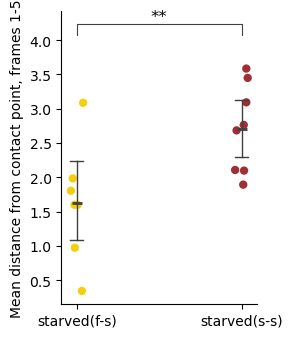

In [12]:
# Plot the values used in the frames 1-5 distance_from_0 test
_, distance_p = mannwhitneyu(distance_1_5['starved(f-s)'].dropna(), distance_1_5['starved(s-s)'].dropna(), alternative='two-sided')

distance_1_5_plot = distance_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved(f-s)', 'starved(s-s)'],
    var_name='condition',
    value_name='distance_from_0'
)

if distance_p < 0.001:
    stars = '***'
elif distance_p < 0.01:
    stars = '**'
elif distance_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['starved(f-s)', 'starved(s-s)'],
    hue='condition',
    palette={'starved(f-s)': '#F3D00E', 'starved(s-s)': '#9E2F35'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['starved(f-s)', 'starved(s-s)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_5_plot['distance_from_0'].max()
ymin = distance_1_5_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-5')
sns.despine()
plt.tight_layout()
plt.show()


condition,starved(f-s),starved(s-s)
file,,
2026-04-28_12-17-10_td5.tracks.feather,2.091278,NaN
2026-05-11_11-19-24_td4.tracks.feather,3.799417,NaN
2026-05-12_14-37-56_td2.tracks.feather,NaN,5.274250
2026-05-12_14-44-29_td4.tracks.feather,4.112341,NaN
2026-05-18_11-59-20_td4.tracks.feather,NaN,3.584553
2026-05-18_12-00-57_td1.tracks.feather,NaN,4.456899
2026-05-19_12-21-24_td1.tracks.feather,NaN,4.817189
2026-05-19_12-25-59_td17.tracks.feather,3.917158,NaN
2026-06-05_12-09-45_td1.tracks.feather,NaN,4.502729


condition
starved(f-s)    2.484776
starved(s-s)    4.893242
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-10, starved(f-s) vs starved(s-s): U=4, p=0.00373


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_40881/3365444999.py:47: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


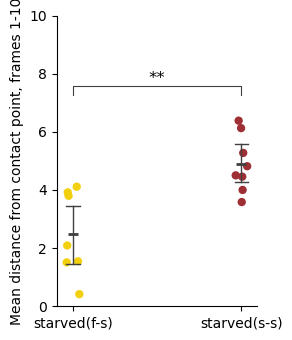

In [ ]:
# Frames 1-10: average distance_from_0 per file, then independent starved(f-s) vs starved(s-s) test
distance_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_10)
print(distance_1_10.mean())

stat, p = mannwhitneyu(distance_1_10['starved(f-s)'].dropna(), distance_1_10['starved(s-s)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-10, starved(f-s) vs starved(s-s): U={stat:.3g}, p={p:.3g}")

# Plot the values used in the frames 1-10 distance_from_0 test
distance_1_10_plot = distance_1_10.reset_index().melt(
    id_vars='file',
    value_vars=['starved(f-s)', 'starved(s-s)'],
    var_name='condition',
    value_name='distance_from_0'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['starved(f-s)', 'starved(s-s)'],
    hue='condition',
    palette={'starved(f-s)': '#F3D00E', 'starved(s-s)': '#9E2F35'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['starved(f-s)', 'starved(s-s)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_10_plot['distance_from_0'].max()
ymin = distance_1_10_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-10')
plt.ylim(0, 10)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/starved-comparison/distance_from_0_mean.pdf', format='pdf')
plt.show()


In [14]:


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/speed_over_time.csv')
df1['role'] = df1['track'].map({0: 'starved', 1: 'fed'})
df1 = df1[df1['role'] == 'starved']
df1['condition'] = 'starved(f-s)'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/speed_over_time.csv')
df2['condition'] = 'starved(s-s)'

df = pd.concat([df1, df2], ignore_index=True)


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_40881/2810859002.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


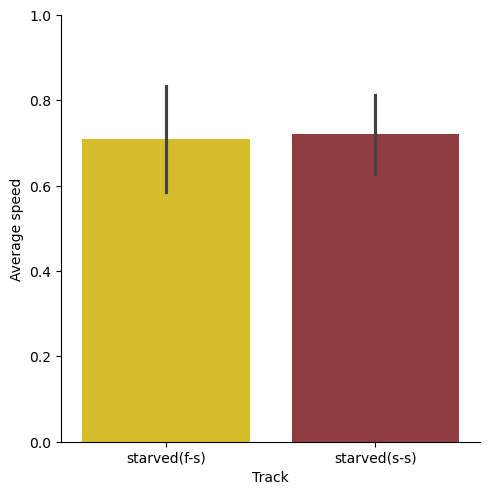

Track starved(f-s) vs track starved(s-s)
Mann-Whitney U = 172
p = 0.8153


In [ ]:
speed_summary = (
    df
    .groupby(['file', 'condition'], as_index=False)['speed']
    .mean()
)

track_order = sorted(speed_summary['condition'].dropna().unique())

fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(
    data=speed_summary,
    x='condition',
    y='speed',
    order=track_order,
    palette={'starved(f-s)': '#F3D00E', 'starved(s-s)': '#9E2F35'},
    errorbar='sd',
    ax=ax,
)

ax.set_xlabel('Track')
ax.set_ylabel('Average speed')
sns.despine(ax=ax)
plt.tight_layout()
plt.ylim(0, 1)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/starved-comparison/avg_speed.pdf', format='pdf')
plt.show()




track_0 = speed_summary.loc[speed_summary['condition'] == track_order[0], 'speed'].dropna()
track_1 = speed_summary.loc[speed_summary['condition'] == track_order[1], 'speed'].dropna()

test = mannwhitneyu(track_0, track_1, alternative='two-sided')

print(f'Track {track_order[0]} vs track {track_order[1]}')
print(f'Mann-Whitney U = {test.statistic:.4g}')
print(f'p = {test.pvalue:.4g}')